In [1]:
import math
import torch

import matplotlib.pyplot as plt
import seaborn as sns

This notebook provides a visual illustration of the difference between minimizing the forward and reverse Kullback-Leibler (KL) divergences, highlighting why this distinction is important in variational inference.

In variational inference (VI), we approximate a complex true posterior $p(z∣x)$ with a simpler distribution $q(z)$ by minimizing some divergence between them — often a KL divergence.

 - *Forward KL*: Minimizing $\text{KL}(p(z∣x)∥q(z))$ encourages covering all modes of the true posterior, because missing probability mass is heavily penalized.
 - _Reverse KL_: Minimizing $\text{KL}(q(z)∥p(z∣x))$ encourages mode-seeking behavior - $q$ will fit tightly around one mode, ignoring others, because putting mass where $p$ is small is heavily penalized.

We define the target distribution as a mixture of two normal distributions:

$$
p(z) = \sum_{k=1}^K \pi_k \mathcal{N}(z; \mu_k, \sigma^2_k)
$$

where $K=2$, $\mu_1=0$, $\mu_2=10$,  $\sigma^2_1 = \sigma^2_2=1$ and $\pi_1= \pi_2 = 0.5$.

The variational distribution is a univariate normal distribution:

$$
q(z; \mu, \sigma^2) = \mathcal{N}(z; \mu, \sigma^2)
$$

In [2]:
def model(x):
    p = torch.distributions.Normal(torch.tensor([0.0, 10.0]), torch.ones(2))
    weights = torch.tensor([0.5, 0.5])
    log_sum = p.log_prob(x) + weights.log()
    return torch.logsumexp(log_sum, dim=-1)


def sample(size):
    mix = torch.distributions.Categorical(torch.ones(2))
    comp = torch.distributions.Normal(torch.tensor([0.0, 10.0]), torch.ones(2))
    dist = torch.distributions.MixtureSameFamily(mix, comp)
    return dist.sample(size)

In [3]:
def KLpq(q, p, samples):
    x = sample(samples).unsqueeze(-1)
    with torch.no_grad():
        log_p = p(x)
    log_q = q.log_prob(x).squeeze()

    return torch.mean(log_p.detach() - log_q)


def KLpqIS(q, p, samples):
    x = q.sample(samples)
    log_q = q.log_prob(x).squeeze()

    with torch.no_grad():
        log_p = p(x)
        w = (log_p - log_q.detach().clone()).exp()

    return torch.mean(w * (log_p.detach() - log_q))


def ELBO(q, p, samples=(1,)):
    x = q.rsample(samples)
    log_q = q.log_prob(x).squeeze()
    log_p = p(x)
    return (log_p - log_q).mean()


def advi(fn, mu, sigma, maximize, grad_samples=(1,), iterations=5000, lr=0.01):
    optimizer = torch.optim.Adam((mu, sigma), lr=lr, maximize=maximize)
    lr_lambda = lambda epoch: 1.0 / math.sqrt(epoch + 1)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    q = torch.distributions.Normal(mu, sigma.exp())
    losses = [fn(q, model, (1000,)).detach()]
    # print(f"{0} LOSS: {losses[-1]}")

    for i in range(1, iterations + 1):
        q = torch.distributions.Normal(mu, sigma.exp())
        loss = fn(q, model, grad_samples)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        if i % 1000 == 0:
            with torch.no_grad():
                losses.append(fn(q, model, (1000,)))
                # print(f"{i} LOSS: {losses[-1]}")
    return torch.distributions.Normal(mu, sigma.exp()), losses

In [4]:
approximations = {}
traces = {}
mu_start = 15.0
sigma_start = 2.0
log_sigma_start = math.log(sigma_start)

Approximate the target distribution by maximizing the ELBO. The gradient is calculated using 1 sample.

In [5]:
mu = torch.tensor([mu_start], requires_grad=True)
log_sigma = torch.tensor([log_sigma_start], requires_grad=True)
elbo_q, elbo_losses = advi(
    ELBO, mu, log_sigma, True, grad_samples=(1,), iterations=100000
)

approximations["ELBO"] = elbo_q
traces["ELBO"] = elbo_losses

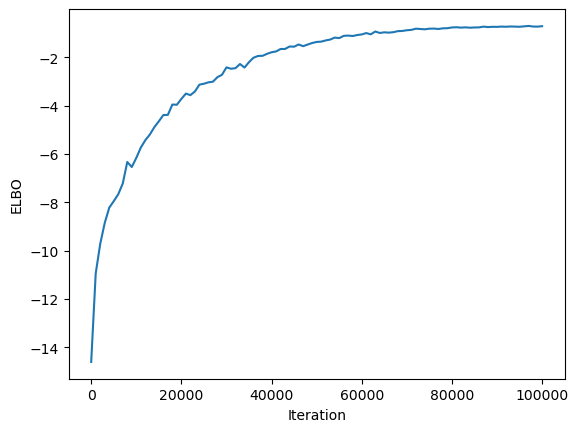

In [6]:
plt.plot(torch.arange(0, len(elbo_losses) * 1000, 1000), elbo_losses)
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.show()

Since we can sample from the target distribution $p$ we can directly approximate $KL(p(z)||q(z; \bm{\lambda}))$ using a Monte Carlo estimator.

$$
\begin{align}
KL(p(z)||q(z; \bm{\lambda})) &= \mathbb{E}_{p(z)} \left[\log\left(\frac{p(z)}{q(z; \bm{\lambda})}\right)\right] \\
& \approx \frac{1}{S}\sum_{s=1}^S \log\left(\frac{p(z_s)}{q(z_s; \bm{\lambda})}\right)
\end{align}
$$

where $\bm{z}_s \sim p(z_s).$

The gradient can be computed in a similar way:

$$
\begin{align}
\nabla_{\bm{\lambda}} KL(p(z)||q(z; \bm{\lambda})) & \approx \frac{1}{S}\sum_{s=1}^S \nabla_{\bm{\lambda}} \log\left(\frac{p(z_s)}{q(z_s; \bm{\lambda})}\right) \\
&= -\frac{1}{S}\sum_{s=1}^S \nabla_{\bm{\lambda}} \log(q(z_s; \bm{\lambda})).
\end{align}
$$


The gradient is calculated using 1, 10, 100, or 1000 samples.

In [7]:
for samples in 1, 10, 100, 1000:
    mu = torch.tensor([mu_start], requires_grad=True)
    log_sigma = torch.tensor([log_sigma_start], requires_grad=True)
    klpq_q, klpq_losses = advi(
        KLpq, mu, log_sigma, False, grad_samples=(samples,), iterations=100000, lr=0.1
    )
    approximations[f"KLpq-{samples}"] = klpq_q
    traces[f"KLpq-{samples}"] = klpq_losses

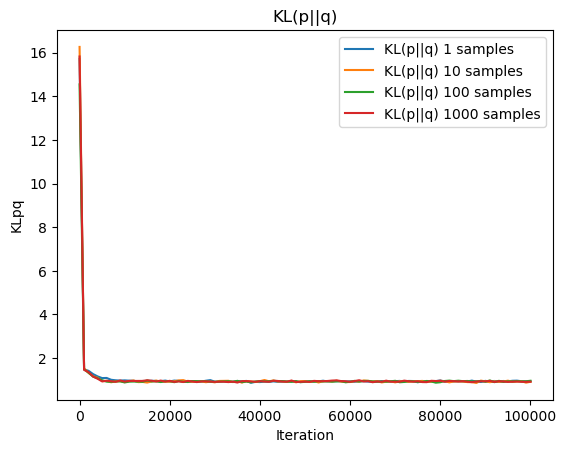

In [8]:
for samples in 1, 10, 100, 1000:
    plt.plot(
        torch.arange(0, len(traces[f"KLpq-{samples}"]) * 1000, 1000),
        traces[f"KLpq-{samples}"],
        label=f"KL(p||q) {samples} samples",
    )
plt.legend()
plt.title("KL(p||q)")
plt.xlabel("Iteration")
plt.ylabel("KLpq")
plt.show()

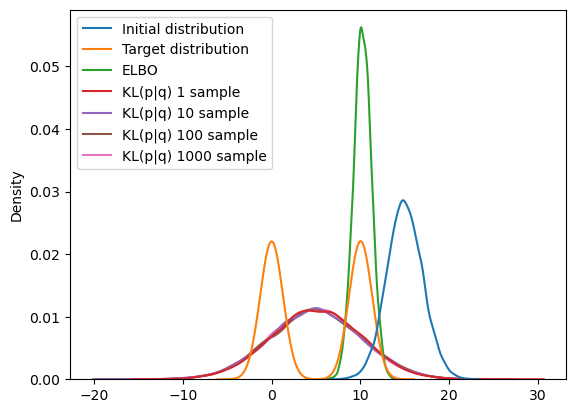

In [9]:
initial_samples = (
    torch.distributions.Normal(torch.tensor([15.0]), torch.tensor([sigma_start]))
    .sample((10000,))
    .squeeze(-1)
    .numpy()
)
target_samples = sample((10000,)).numpy()

df = {
    "Initial distribution": initial_samples,
    "Target distribution": target_samples,
    "ELBO": elbo_q.sample((10000,)).squeeze(-1).numpy(),
}
for samples in 1, 10, 100, 1000:
    df[f"KL(p|q) {samples} sample"] = (
        approximations[f"KLpq-{samples}"].sample((10000,)).squeeze(-1).numpy()
    )
sns.kdeplot(df)
plt.show()

Approximate the target distribution by minimizing the KL(p|q) using importance sampling and using the instrument distribution $q$

$$
\begin{align}
KL(p(z)||q(z; \bm{\lambda})) &= \mathbb{E}_{p(z)} \left[\log\left(\frac{p(z)}{q(z; \bm{\lambda})}\right)\right]\\
&= \mathbb{E}_{q(z; \bm{\lambda})} \left[\frac{p(z)}{q(z; \bm{\lambda})} \log\left(\frac{p(z)}{q(z; \bm{\lambda})}\right)\right] \\
& \approx \frac{1}{S}\sum_{s=1}^S \frac{p(z_s)}{q(z_s; \bm{\lambda})} \log\left(\frac{p(z_s)}{q(z_s; \bm{\lambda})}\right), \quad z_s \sim q(z; \bm{\lambda})
\end{align}
$$

The gradient can be computed in a similar way. Notice that $\mathbb{E}_{p(z)}[\log p(z)]$ does not depend on $\bm{\lambda}$, therefore minimizing $KL(p||q)$ is equivalent to minimizing an objective $L_{KL}(\bm{\lambda})$ based on cross-entropy with respect to variational parameters,

$$L_{KL}(\lambda) = - \mathbb{E}_{p(z)} [\log q(z; \bm{\lambda})].$$

Thus we can first take the gradient and then use the importance samplig estimator, giving:

$$\nabla L_{KL}(\lambda) = -\sum_{s=1}^S \frac{p(z_s)}{q(z_s; \bm{\lambda})} \nabla\log q(z_s ; \bm{\lambda}) , \quad z_s \sim q(z; \bm{\lambda}).$$

The gradient is calculated using either 1, 10, 100, or 1000 samples.

In [10]:
for samples in 1, 10, 100, 1000:
    mu = torch.tensor([mu_start], requires_grad=True)
    log_sigma = torch.tensor([log_sigma_start], requires_grad=True)
    klpq_q, klpq_losses = advi(
        KLpqIS, mu, log_sigma, False, grad_samples=(samples,), iterations=100000, lr=0.1
    )
    approximations[f"KLpqIS-{samples}"] = klpq_q
    traces[f"KLpqIS-{samples}"] = klpq_losses

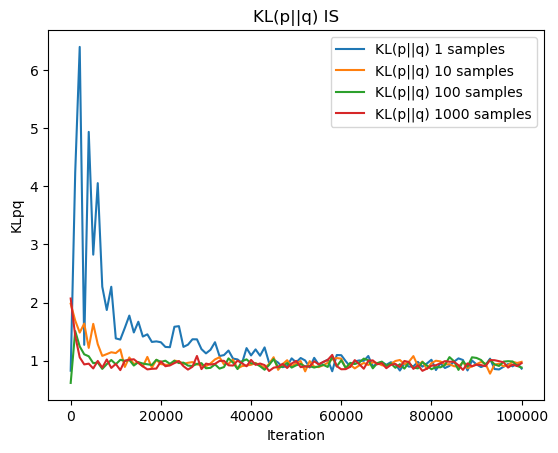

In [11]:
for samples in 1, 10, 100, 1000:
    plt.plot(
        torch.arange(0, len(traces[f"KLpqIS-{samples}"]) * 1000, 1000),
        traces[f"KLpqIS-{samples}"],
        label=f"KL(p||q) {samples} samples",
    )
plt.legend()
plt.title("KL(p||q) IS")
plt.xlabel("Iteration")
plt.ylabel("KLpq")
plt.show()

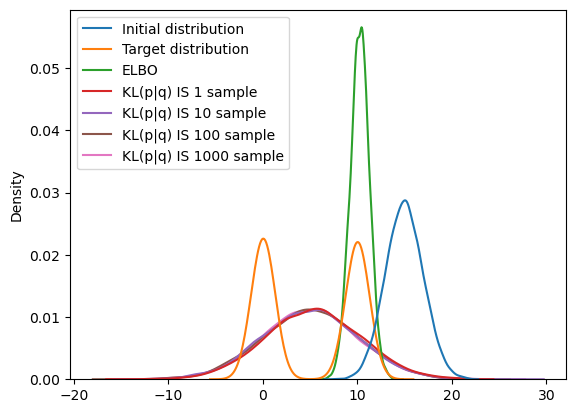

In [12]:
initial_samples = (
    torch.distributions.Normal(torch.tensor([15.0]), torch.tensor([sigma_start]))
    .sample((10000,))
    .squeeze(-1)
    .numpy()
)
target_samples = sample((10000,)).numpy()

df = {
    "Initial distribution": initial_samples,
    "Target distribution": target_samples,
    "ELBO": elbo_q.sample((10000,)).squeeze(-1).numpy(),
}
for samples in 1, 10, 100, 1000:
    df[f"KL(p|q) IS {samples} sample"] = (
        approximations[f"KLpqIS-{samples}"].sample((10000,)).squeeze(-1).numpy()
    )
sns.kdeplot(df)
plt.show()